In [1]:
import matplotlib
import platform
print ("Operating system: ", platform.system())
if "Linux" in platform.system():
    %matplotlib tk
else:
    %matplotlib qt
    
#
import matplotlib.pyplot as plt
%autosave 180
%load_ext autoreload
%autoreload 2
import numpy as np

#
import scipy
import os
import time

#
from calibration.CalibrationTools import CalibrationTools, get_binary_std_map, get_rois_stardist2d, get_img_std
from drift.drift import (make_template, compute_drift_multi_frames, correct_drift, 
                         correct_drift_single_frame, template_generation, 
                         plot_mean_vs_template, make_motion_template_and_correct_data)
from utils.utils import smooth_ca_time_series, compute_dff0



Operating system:  Linux


Autosaving every 180 seconds


In [2]:
#######################################################################
########### LOAD PRE-BMI DATA (e.g. 10-15mins recording) ##############
#######################################################################
fname = r'F:\bmi\DON10775\22-07-25\calibration\Image_001_001.raw'
#fname = '/media/cat/4TB/donato/DON-009460/22-06-21/calibration/Image_001_001.raw'
#fname = '/media/cat/4TB/donato/DON-008499/mouse2_calibration/Image_001_001.raw'
fname = '/media/cat/4TBSSD/donato/test/data/Image_001_001.raw'
#fname = '/home/cat/data/donato/bscope_tests/8499/data/Image_001_001.raw'
#fname = '/media/cat/4TB/donato/DON-10798/22-07-26/calibration/Image_001_001.raw'
fname = '/media/cat/4TB1/donato/DON-10795/22-07-30/calibration/Image_001_001.raw'
fname = '/home/cat/code/bmi/Link to 22-07-30/data_original/Image_001_001.raw'

# 
bmi_c = CalibrationTools(fname)

#
bmi_c.smooth_ca_time_series = smooth_ca_time_series
bmi_c.compute_dff0 = compute_dff0

#
bmi_c.subsample = 10 # for std computation downsample to every N'th frame; the more frames the better the rois;
                  #   TODO: use correlation instead?! might be much faster; it is quit fast in other implemenations


memmap :  (70000, 512, 512)


In [3]:
##################################################################
############### MOTION CORRECTION STEP ###########################
##################################################################
# 
if False:
    start = time.time()
    bmi_c = make_motion_template_and_correct_data(bmi_c)
    plot_mean_vs_template(bmi_c)
    print ("total processing time: ", time.time()-start, " sec")
else:
    print ("Skipping template makgin step: ")
    bmi_c.template = np.mean(bmi_c.data[:1000],axis=0)
    
print ("DONE...")

Skipping template makgin step: 
DONE...


In [4]:
###################################################################
################# GET STD MAP TO GET CELL FOOTPRINTS ##############
###################################################################
# 
start = time.time()

# Filter data, then make map 
if True:
    std_map = bmi_c.filter_data_make_std_map()

# # just make std, and divide by mean
# # DOESN"T SEEM TO WORK WELL in M1; 
# MIGHT TRY IN CA3 IMPLANTS
# else:
#     idx = np.arange(bmi_c.data.shape[0])[::bmi_c.subsample]
#     data_sparse = bmi_c.data[idx]
    
#     # compute std
#     std = np.std(data_sparse.astype('float32'), axis=0)
    
#     # compute mean
#     mean = np.mean(data_sparse.astype('float32'), axis=0)
    
#     #
#     std_map = (std/mean)*100
    
#     std_map = std

#
print ("total processing time: ", time.time()-start, " sec")
print ("...DONE...")


data into analysis:  (7000, 512, 512)
 gaussian filter width:  1 , order:  0
done filtering... (TO CHECK which axis are we filtering!!)
total processing time:  116.0404896736145  sec
...DONE...


In [5]:
#################################################################
########### MAKE BINARY MAP FOR CELL REGISTRATOIN ###############
#################################################################

# get binary map
vmax = 300
smin, smax = get_binary_std_map(std_map,vmax)


In [6]:
##################################################

bmi_c, img_std = get_img_std(smin, smax, std_map, bmi_c)


max proj values (vmin, vmax):  60.37124337065404 67.44254566882731


In [22]:
#########################################################
########### GENERATE CELL SEGMENTATION ##################
#########################################################
min_size_roi = 100  #<---- increase to exclude really small cells
max_size_roi = 800  #<----- decrease to exclude multi-cell artificats
bmi_c.rois, bmi_c.footprints = get_rois_stardist2d(img_std,
                                               min_size_roi,
                                               max_size_roi)

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None
None
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
1/1 [==============================] - 1s 654ms/step


looping over cells: 100%|██████████| 48/48 [00:00<00:00, 822.41it/s]


In [76]:
#########################################################
########### REORDER CELLS BY SNR OR F0 ##################
#########################################################
order_type = 'snr'  # 'snr' or 'f0'
bmi_c.reorder_cells_by_snr_or_f0(order_type)  # this function also coputes the snr / f0s of the cells


computing roi traces for SNR indexing: 100%|██████████| 7000/7000 [00:16<00:00, 433.31it/s]


In [77]:
#############################################################
############## VISUALIZE ALL CELLS AND TRACES ###############
#############################################################
#
bmi_c.scale=1   
# <--- decrease to see cell traces better
bmi_c.trace_subsample = 10       # Subsample the time series to go faster;

# visualize traces
bmi_c.visualize_traces_snr_order(std_map)

# 

memmap :  (70000, 512, 512)


In [80]:
###############################################################
########### SELECT ENSEMBEL CELLS AND VISUALIZE ###############
###############################################################

# save ensemble rois
bmi_c.ensemble1 = [1,4]
bmi_c.ensemble2 = [6,12]
both = np.hstack((bmi_c.ensemble1, bmi_c.ensemble2))
print ("all cells:", both)

#
bmi_c.show_traces_ids(both)


all cells: [ 1  4  6 12]


### COMPUTE THE MIN AND MAXES FOR THE SELECTED ENSMEMLES

Some important points:

1. For now we are working in pixel absolute values for each cell.  

2. A better option might be to find the maximum peak of a cell during a window and then save that value and normalize all future events by that value. (note: any online BMI filtering/chagnig of data will need to account for this).


In [79]:
# ######################################################################
# ########### RECOMPUTE TRACES WITH SINGLE FRAME PRECISION #############
# ######################################################################
bmi_c.trace_subsample = 1        # Subsample the time series to go faster;

# visualize traces
bmi_c.compute_traces2(std_map, both)

print ("DONE...")

plotting cells:  [ 1  4  6 12]


100%|██████████| 70000/70000 [00:17<00:00, 3914.17it/s]


DONE...


In [73]:
#############################################
########### RUN THRSHOLD SETTER #############
#############################################
# 
bmi_c.sample_rate = 30
bmi_c.post_reward_lockout = 10   # reward lockout in seconds
bmi_c.balance_ensemble_rewards_flag = False   #this makes sure that both ensembles elicit a similar number of random rewards
bmi_c.rois_smooth_window = 15     # of frames to use to smooth the realtime signal
bmi_c.smooth_diff_function_flag = True    # use a kernel window to smooth current value

#
bmi_c.reward_rate = 0.3

# find 30% reward threshold
# We have 3 options: 
#   1) rewarding  E1-E2 going above some threshold
#   2) rewarding E2-E1 going above some threhosld
#   3) rewarding both
# The challenge is mapping the ensemble states to tone/stimulus space

#gr.find_reward_thresholds_low_and_high()
bmi_c.find_reward_thresholds_high()  # this only rewards when sound passes specific level

# this option rewards both ensembles 
#normalize_peaks = True   # this flag normalizes the peaks to make sure one ensembel
#                         # doesn't completely dominate the other;
                          # TODO: make sure that this is implemented in the bmi online component also
#bmi_c.find_reward_thresholds_absolute(normalize_peaks)


#
print ("thresholds: ", bmi_c.high)

########################################
bmi_c.plot_rewarded_ensembles()

print (bmi_c.high)
bmi_c.high = bmi_c.high*0.9

COMPUTED # of roi traces:  46


100%|██████████| 69985/69985 [00:01<00:00, 56988.99it/s]


low, high:  -1.4309416848882612 0.9427472782380064
nsec recording:  2333 max # of random rewards (i.e. every 30sec)  77
 @30% reward:  23
updated rewards #:  26 -0.5983058169645741 0.39418180800384206
thresholds:  0.39418180800384206
0.39418180800384206


In [74]:
#############################################
########### RUN THRSHOLD SETTER #############
#############################################

# save all data to disk
# also add the tone values here as well that will be used for the experiment
bmi_c.low_freq = 2000
bmi_c.high_freq = 18000

# save cell pixel footprints locations as 2 column array inside list
cells = []
for k in range(4):
    temp = bmi_c.footprints[both[k]]
    temp1 = temp[0]
    temp2 = temp[1]
    temp = np.vstack((temp1,temp2))
    cells.append(temp)

# also grab contours of cells; both contains all cell ids
contours = bmi_c.compute_contour_map(std_map, both)
print ("len: ", len(contours))        

# also grab contours of cells; both contains all cell ids
contours_all_cells = bmi_c.compute_contour_map(std_map, np.arange(len(bmi_c.footprints)))
contours_all_cells = np.array(contours_all_cells, dtype=object)


# save individual pixels of each cell - currently implemented in BMI
np.savez(os.path.join(os.path.split(os.path.split(fname)[0])[0],
                        'rois_pixels_and_thresholds.npz'),
            cell0_footprint = cells[0],
            cell1_footprint = cells[1],
            cell2_footprint = cells[2],
            cell3_footprint = cells[3],
            
            #
            cell0_contour = contours[0],
            cell1_contour = contours[1],
            cell2_contour = contours[2],
            cell3_contour = contours[3],
         
            #
            contours_all_cells = contours_all_cells,
            cell_f0s = bmi_c.roi_f0s,
            cell_centres = np.int32(bmi_c.rois)[both],
            cell_ids = both,
            all_rois = np.int32(bmi_c.rois),
            low_threshold = bmi_c.low,
            high_threshold = bmi_c.high,
            low_freq = bmi_c.low_freq,
            high_freq = bmi_c.high_freq,
            all_roi_traces_submsampled = bmi_c.roi_traces,
            ensemble_roi_traces_dff_smooth = bmi_c.roi_traces_fullres_dff_smooth,
            sample_rate = bmi_c.sample_rate,
            post_reward_lockout = bmi_c.post_reward_lockout,
            balance_ensemble_rewards_flag = bmi_c.balance_ensemble_rewards_flag,
            rois_smooth_window = bmi_c.rois_smooth_window,
            smooth_diff_function_flag = bmi_c.smooth_diff_function_flag,
            calibration_template = bmi_c.template,
            footprints = bmi_c.footprints
             
        )


len:  4


In [55]:
print (bmi_c.template)

[[236.496 236.58  230.244 ... 241.44  245.769 241.934]
 [236.811 233.512 235.515 ... 244.499 239.954 239.103]
 [236.811 234.168 231.068 ... 240.488 235.467 239.639]
 ...
 [232.637 230.419 228.92  ... 230.221 225.757 231.88 ]
 [232.637 228.732 224.605 ... 232.338 227.677 229.728]
 [228.623 227.137 230.159 ... 231.409 227.746 230.466]]


### SOME ADDTIONAL TOOLS FOR ANALYSISE OF THE BMI LONGER SESSIONS

In [43]:
###############################################################################
#################### VAISUALIZE BLEACHING ON LONGER RECORDINGS ################
###############################################################################
#
fname = '/home/cat/data_temp/DON-10798/22-07-26/data/Image_001_001.raw'
n_frames = 90000

#
data = bmi_c.load_data_mmap(fname, n_frames)

#
bmi_c.trace_subsample = 1        # Subsample the time series to go faster;

# visualize traces
bmi_c.compute_and_plot_traces2_datafile(data, std_map, both)

loaded:  /home/cat/data_temp/DON-10798/22-07-26/data/Image_001_001.raw (90000, 512, 512)
plotting cells:  [ 0  3 29 42]
[ 0  3 29 42]


In [1]:
from drift.drift import compute_drift_from_fname_and_template
import numpy as np

data = np.load('/home/cat/data_temp/DON-10798/22-07-26/rois_pixels_and_thresholds.npz',allow_pickle=True)

template = data['calibration_template']

#
n_cores = 8
fname = '/home/cat/data_temp/DON-10798/22-07-26/data/Image_001_001.raw'
shifts, corrs = compute_drift_from_fname_and_template(fname, 
                                                      template,
                                                      n_cores)


computing motion on:  /home/cat/data_temp/DON-10798/22-07-26/data/Image_001_001.raw
LOADED DATA SHAPE:  (90000, 512, 512)


phase corr computation:   0%|          | 0/11250 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

phase corr computation: 100%|██████████| 11250/11250 [12:30<00:00, 14.99it/s]


TODO: undo interpolation for drift with better function


In [11]:
#
np.save('/home/cat/shifts.npy', shifts)
np.save('/home/cat/corrs.npy', corrs)

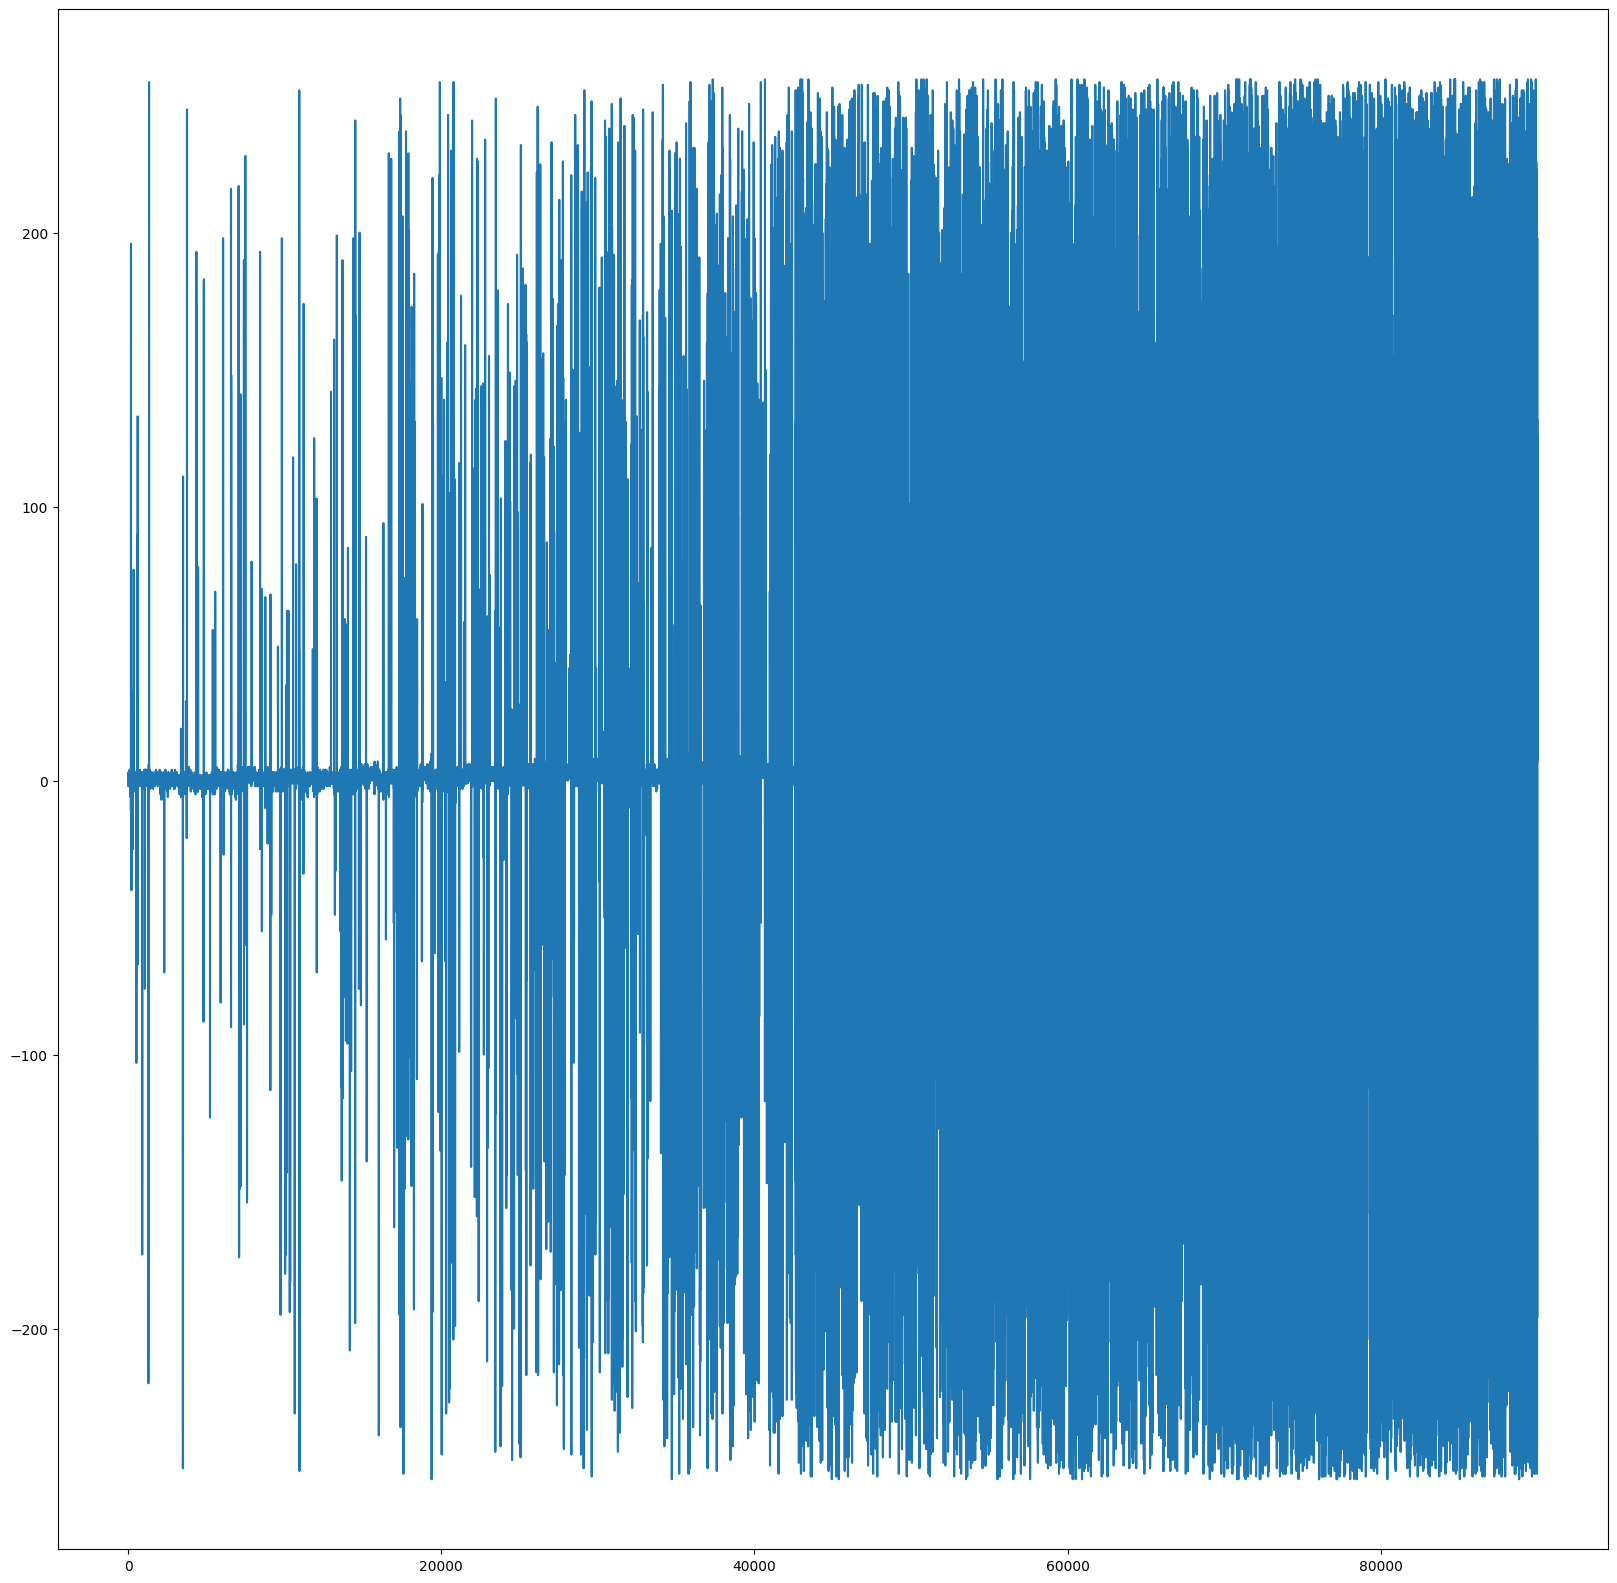

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
plt.plot(shifts[:,0])
plt.show()

In [28]:
data = np.load(r'E:\bmi_backup\DON8460\22-07-13\databmi_results.npz')
ensembles = data['ensemble_activity']

temp = data['ttl_voltages']

print (ensembles.shape)
plt.figure()
plt.plot(temp)
#plt.plot(ensembles[0])
#plt.plot(ensembles[1])
plt.show()

(2, 1000)


In [35]:
#
print (gr.diff.shape)
plt.figure(0)
plt.plot(gr.diff)
plt.show()

(20000,)


In [ ]:
#######################################################
######### MANUAL ROI SELECTOR - DO NOT DELETE #########
#######################################################

# # importing the module
# import cv2

# # function to display the coordinates of
# # of the points clicked on the image
# def click_event(event, x, y, flags, params):

#     # checking for left mouse clicks
#     if event == cv2.EVENT_LBUTTONDOWN:

#         # displaying the coordinates
#         # on the Shell
#         print(x, ' ', y)
#         rois_manual.append([x,y])

#         # displaying the coordinates
#         # on the image window
#         #font = cv2.FONT_HERSHEY_SIMPLEX
#         img[y-2:y+3, x-2:x+3] = 0
   
#         #cv2.putText(img, str(x) + ',' +
#         #            str(y), (x,y), font,
#         #            .3, (255, 0, 0), 2)
#         cv2.imshow('image', img)

#     # checking for right mouse clicks	
#     #if event==cv2.EVENT_RBUTTONDOWN:
#     #    
#     #    np.save()

# # driver function
# if __name__=="__main__":
    
#     global rois_manual
    
#     rois_manual = []
    
#     # reading the image
#     #img = cv2.imread('lena.jpg', 1)
#     img = std_map.copy()
    
#     img = cv2.resize(img, (int(img.shape[0]*1.5),
#                            int(img.shape[1]*1.5))) 

#     # displaying the image
#     cv2.imshow('image', img)

#     # setting mouse handler for the image
#     # and calling the click_event() function
#     cv2.setMouseCallback('image', click_event)

#     # wait for a key to be pressed to exit
#     cv2.waitKey(0)

#     # close the window
#     cv2.destroyAllWindows()

# print (" DONE LABELING: ")
# print ("ROIS: ", rois_manual)



In [2]:
data = np.load('/media/cat/4TB/donato/BSCOPE_tests/rois_pixels_and_thresholds.npz')

low_thresh = data['low_threshold']
high_thresh = data['high_threshold']

print (low_thresh, high_thresh)



-768.7697339352011 546.5230278373468


In [10]:

octave_size = 0.25

# 
def get_octave_frequencies(low_freq,
                  high_freq,
                  octave_size):
    
    #
    octaves = []
    
    #
    octaves.append(low_freq)
    temp = low_freq
    while True:
        temp = temp * (1+octave_size)
        if temp>high_freq:
            break
        octaves.append(temp)

    return octaves
#
octaves = get_octave_frequencies(2000,
              18000,
              octave_size)
print (len(octaves),octaves)
      
    


10 [2000, 2500.0, 3125.0, 3906.25, 4882.8125, 6103.515625, 7629.39453125, 9536.7431640625, 11920.928955078125, 14901.161193847656]
